# HI, HeI and CaII population

- 2020.06.10   k.i. 
- 2020.07.16   k.i., u.k.    population plot
- 2020.07.20   k.i.  add Src & tau_1D in both CloudModel.py    
- 2020.07.24   k.u.,k.i.  Transition_heatmap
- 2020.07.29   k.i.,k.u.  rename to HHeCa.jpynb,   cal_SE_with_Pg_Te_()

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

C:\Users\ichim\AppData\Local\Temp\ipykernel_14376\875321342.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra.Util import HelpUtil
from spectra.Visual import Plotting  #, Grotrian
from spectra.Atomic import LTELib
from spectra.Function.SEquil import SELib
from spectra.Atomic import Hydrogen
from spectra.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra import Constants as Cst
from spectra.Function.SlabModel import CloudModel


## Create atomic model

In [3]:
# Atomic model
import os

conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H.conf" )
atom_H, wMesh_H, path_dict_H = Atom.init_Atom_(conf_path , is_hydrogen=True)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/He.conf" )
atom_He, wMesh_He, path_dict_He = Atom.init_Atom_(conf_path , is_hydrogen=False)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/Ca_II.conf" )
atom_Ca, wMesh_Ca, path_dict_ca = Atom.init_Atom_(conf_path , is_hydrogen=False)


In [4]:
HelpUtil.help_( atom_He )
path_dict_He
l = line_list(atom_He)


------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Atom
|- Z                       int                                  v: 2
|- Mass                    float                                v: 4.0026
|- Abun                    float                                v: 0.09772372209558111
|- nLevel                  int                                  v: 27
|- nLine                   int                                  v: 205
|- nCont                   int                                  v: 26
|- nTran                   int                                  v: 231
|- nRL                     int                                  v: 39
|- Level                   struct array                         s: (27,)
  |-  erg                  float64                              s: (27,)
  |- 

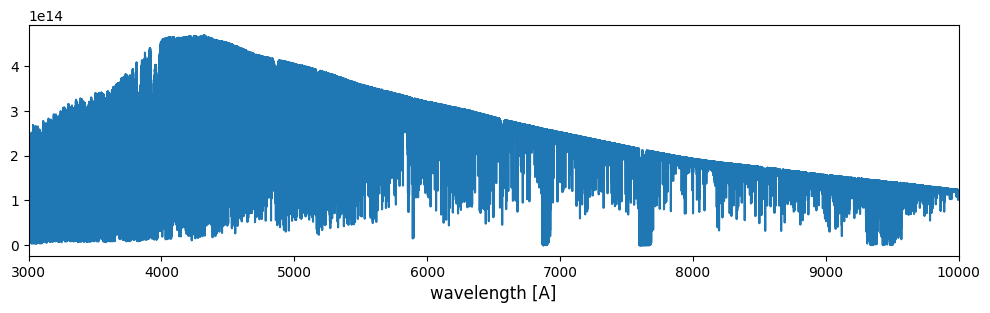

In [5]:
#  prepare solar radiation spectrum
import copy

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vt=5.E5)
solar_spec_H = Radiation.init_Radiation_()
solar_spec_He = Radiation.init_Radiation_()
solar_spec_Ca = Radiation.init_Radiation_()
wl0 = solar_spec_H.solar[0,:]*1E8  # wavelength of background spectrum [A]
wl_air = BasicP.vacuum_to_air_(wl0,'AA')
Isolar = solar_spec_H.solar[1,:].copy()   # solar spectrum intensity    "    [erg/cm^3/s/str]
solar_spec_H.solar[1,:] *= 0.5    # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_He.solar[1,:] *= 0.5   # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_Ca.solar[1,:] *= 0.5   # solar spectrum mean intensity    "    [erg/cm^3/s/str]

solar_spec_H0 = copy.deepcopy(solar_spec_H)
solar_spec_He0 = copy.deepcopy(solar_spec_He)
solar_spec_Ca0 = copy.deepcopy(solar_spec_Ca)

fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=100)
ax.plot(wl0, Isolar)
ax.set_xlim(3000, 10000)
#ax.set_xlim(10820, 10840) ; ax.set_ylim(0,1.2e14)
#ax.set_yscale("log") ; ax.set_ylim(1e7,1e15)
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()


In [6]:
HelpUtil.help_(solar_spec_H)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Radiation
|- backRad                 ndarray                              s: (2, 3754678)
|- PI_intensity            ndarray                              s: (8, 41)


In [7]:
HelpUtil.help_( wMesh_He )

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Wavelength_Mesh
|- Cont_mesh               ndarray                              s: (26, 41)
|- Cont_Coe                struct array                         s: (26,)
  |-  idxI                 int32                                s: (26,)
  |-  idxJ                 int32                                s: (26,)
  |-  w0                   float64                              s: (26,)
  |-  nLambda              int32                                s: (26,)
|- Line_mesh               ndarray                              s: (7965,)
|- Line_mesh_idxs          ndarray                              s: (205, 2)
|- Line_absorb_prof        ndarray                              s: (7965,)
|- Line_Coe                struct array                

## output intensity profile from a slab without background (emission)

In [8]:
solar_spec_He.solar.shape

(26, 41)

In [9]:
def enhance_EUV(solar_spec,wMesh,ampl,wleuv=504.):
    
    # amp_euv = 10.  #  enhance EUV radiation for He 10830

    solar_spec2 = copy.deepcopy(solar_spec)
    wleuv *= 1e-8
    print("wleuv=",wleuv)

    ii = np.where(solar_spec2.solar[0,:] < wleuv)[0]
    solar_spec2.solar[1, ii] *= ampl
    
    return solar_spec2


In [10]:
# from spectra.Function.SlabModel import CloudModel
Te = 8000.
Nh = 1*1e11
Ne = 2e10
Vt = 5e5            #   cm/s
depth = 1.E4 * 1.E5 #   km *1e5
ampl = 1

solar_spec_He = enhance_EUV(solar_spec_He0,wMesh_He,ampl)

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vt=Vt)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
SE_He, Rate_He = SELib.cal_SE_with_Nh_Te_(atom_He, slab, wMesh_He, solar_spec_He, SE_H.n_SE)  #  level populations etc.
lHe = CloudModel.SE_to_slab_0D_(atom_He, slab, SE_He, depth=depth)      # hydrogen lines intensity
SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # hydrogen lines intensity


wleuv= 5.04e-06


C:\home\Python\spectra\spectra\Function\SlabModel\CloudModel.py:47: RuntimeWarning: invalid value encountered in divide
  Src   : T_ARRAY = ( Aji * nj ) / ( Bij * ni - Bji * nj )


In [11]:
HelpUtil.help_(SE_He)
HelpUtil.help_(Rate_He)
HelpUtil.help_(lHe)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
SE_Container
|- n_SE                    ndarray                              s: (27,)
|- n_LTE                   ndarray                              s: (27,)
|- nj_by_ni                ndarray                              s: (231,)
|- wave_mesh_shifted_1d    ndarray                              s: (7965,)
|- absorb_prof_1d          ndarray                              s: (7965,)
|- Line_mesh_idxs          ndarray                              s: (205, 2)
|- Jbar                    ndarray                              s: (205,)
------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
----------------------------------

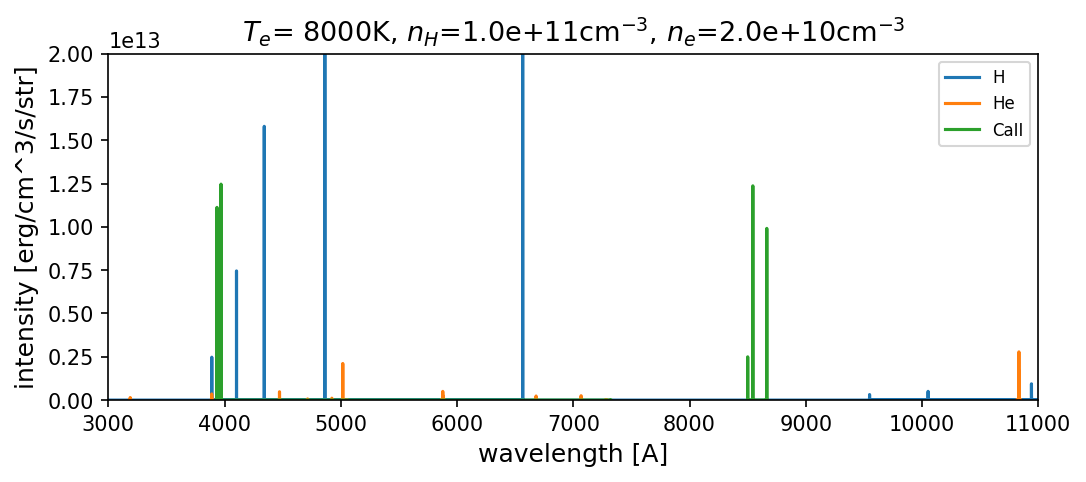

In [12]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(lH.wl_1D*1e8,lH.prof_1D,label='H')
ax.plot(lHe.wl_1D*1e8,lHe.prof_1D,label='He')
ax.plot(lCa.wl_1D*1e8,lCa.prof_1D,label='CaII')
ax.set_ylim(1e9,1E14)
#ax.set_xlim(500, 50000)
#ax.set_xscale("log")
ax.set_xlim(3000, 11000)
#ax.set_yscale("log")
ax.set_ylim(0, 2e13)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$, $n_e$={2:5.1e}cm$^{{-3}}$".format(Te, Nh, Ne),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()

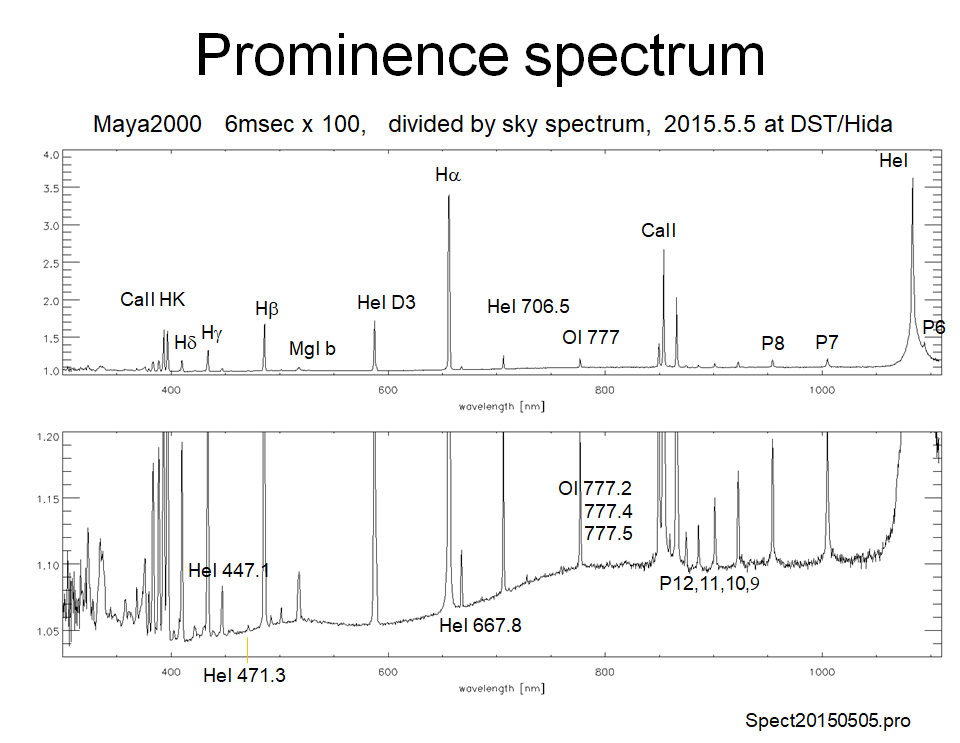

# extract lines of interest 
## plot intensity profile from a slab with/without continuum background

### cloud model: $\qquad$    $I_{out} = I_{c} e^{-\tau} + S (1-e^{-\tau})$

In [13]:
#-------------------------------------------------------------
def extract_line(l, wl, Ic=0.):
#-------------------------------------------------------------
# extract line profile in a wl interval from l-structure
# wl[:]  -- in A 
# Ic  -- background intensity

    nw = wl.size
    profe = np.zeros(nw)
    tau = np.zeros(nw)

    w0 = l.w0 *1e8
    jj = np.where((w0 > min(wl)) & (w0 < max(wl)))[0]

    for j in jj:
        idx1 = l.Line_mesh_idxs[j,0] 
        idx2 = l.Line_mesh_idxs[j,1]
        tau1 = np.interp(wl, l.wl_1D[idx1:idx2]*1e8, l.tau_1D[idx1:idx2])
        prof1 = l.Src[j] * (1.-np.exp(-tau1))
        #print('Ic, Src=',Ic,l.Src[j])
        tau += tau1
        profe += prof1
        
    prof = Ic*np.exp(-tau) + profe
    
    ldat = {
        "intens": prof,
        "tau": tau,
        "src": max(l.Src[jj]),
    }
    
    return ldat



In [14]:
def wlarr(wl00,vmax,dv):
# return wl[:]  in A,  vmax, dv  in km/s

    dw = dv/Cst.c_*wl00*1e5
    wmin = wl00 - dw*vmax/dv
    wmax = wl00 + dw*vmax/dv
    nw = int((wmax-wmin)/dw) + 1
    wl = np.linspace(wmin,wmax,nw)
    return wl


vmax = 150. ; dv = 1.  # km/s

H_line = 6563. +1.5    ;  wlH = wlarr(H_line,vmax,dv)     ;  bgH = np.interp(wlH, wl0, Isolar)
He_line = 10830. +3.   ;  wlHe = wlarr(He_line,vmax,dv)   ;  bgHe = np.interp(wlHe, wl0, Isolar)
Ca_line = 8542. +2.   ;  wlCa = wlarr(Ca_line,vmax,dv)   ;  bgCa = np.interp(wlCa, wl0, Isolar)
IcH = np.max(bgH)
IcHe = np.max(bgHe)
IcCa = np.max(bgCa)


w6563 = wlarr(6563.,vmax,dv)
w10830 = wlarr(10830.,vmax,dv)
w8542 = wlarr(8542.,vmax,dv)
w3934 = wlarr(3934.,vmax,dv)

Ic6563 = np.min(np.interp(w6563, wl0, Isolar))
Ic10830 = np.max(np.interp(w10830, wl0, Isolar))
Ic8542 = np.max(np.interp(w8542, wl0, Isolar))
Ic3934 = np.min(np.interp(w3934, wl0, Isolar))


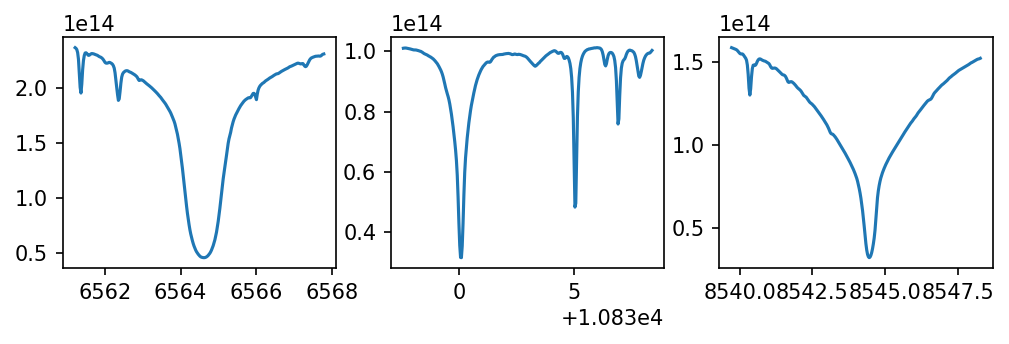

In [15]:
### plot a line profile in solar spectrum ###
fig, axs = plt.subplots(1,3, figsize=(8,2), dpi=150)
axs[0].plot(wlH,bgH)
axs[1].plot(wlHe,bgHe)
axs[2].plot(wlCa,bgCa)


In [16]:
def line_erg(l,wline,vmax,dv):
    wl = wlarr(wline,vmax,dv)
    ldat = extract_line(lHe,wl)
    lerg = np.sum(ldat["intens"])*(wl[1]-wl[0])*1e-8
    return lerg

line_erg(lHe,10830.,vmax,dv)   # erg/cm^2/s



24829.315969330244

Text(0.5, 1.0, '$\\tau=$150.37')

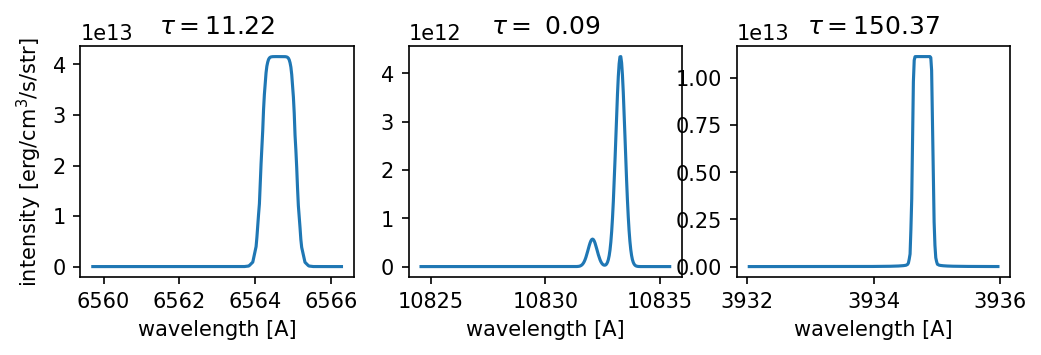

In [17]:
##  plot line profiles

fig, axs = plt.subplots(1,3, figsize=(8,2), dpi=150)

l6563 = extract_line(lH,w6563)
axs[0].plot(w6563,l6563["intens"])
axs[0].set_xlabel("wavelength [A]", fontsize=10)
axs[0].set_ylabel("intensity [erg/cm$^3$/s/str]", fontsize=10)
axs[0].set_title(r"$\tau=$"+f"{np.max(l6563['tau']):5.2F}")
l10830 = extract_line(lHe,w10830)
axs[1].plot(w10830,l10830["intens"])
axs[1].set_xlabel("wavelength [A]", fontsize=10)
axs[1].set_title(r"$\tau=$"+f"{np.max(l10830['tau']):5.2F}")
#l8542 = extract_line(lCa,w8542)
#axs[2].plot(w8542,l8542["intens"])
#axs[2].set_xlabel("wavelength [A]", fontsize=10)
#axs[2].set_title(r"$\tau=$"+f"{np.max(l8542['tau']):5.2F}")
l3934 = extract_line(lCa,w3934)
axs[2].plot(w3934,l3934["intens"])
axs[2].set_xlabel("wavelength [A]", fontsize=10)
axs[2].set_title(r"$\tau=$"+f"{np.max(l3934['tau']):5.2F}")


Text(0.5, 1.0, '$S/I_c=$ 0.57')

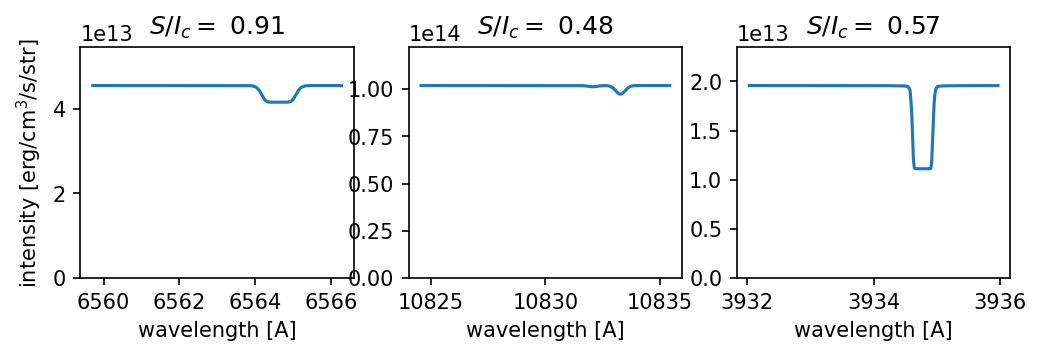

In [18]:
##  plot line profiles with background continuum

fig, axs = plt.subplots(1,3, figsize=(8,2), dpi=150)

l6563 = extract_line(lH,w6563,Ic=Ic6563)
axs[0].plot(w6563,l6563["intens"])
axs[0].set_xlabel("wavelength [A]", fontsize=10)
axs[0].set_ylabel("intensity [erg/cm$^3$/s/str]", fontsize=10)
axs[0].set_ylim(0,max(l6563["intens"])*1.2)
axs[0].set_title(r"$S/I_c=$"+f"{l6563['src']/Ic6563:5.2F}")
l10830 = extract_line(lHe,w10830,Ic=Ic10830)
axs[1].plot(w10830,l10830["intens"])
axs[1].set_xlabel("wavelength [A]", fontsize=10)
axs[1].set_ylim(0,max(l10830["intens"])*1.2)
axs[1].set_title(r"$S/I_c=$"+f"{l10830['src']/Ic10830:5.2F}")
#l8542 = extract_line(lCa,w8542,Ic=Ic8542)
#axs[2].plot(w8542,l8542["intens"])
#axs[2].set_xlabel("wavelength [A]", fontsize=10)
#axs[2].set_ylim(0,max(l8542["intens"])*1.2)
#axs[2].set_title(r"$S/I_c=$"+f"{l8542['src']/Ic8542:5.2F}")
l3934 = extract_line(lCa,w3934,Ic=Ic3934)
axs[2].plot(w3934,l3934["intens"])
axs[2].set_xlabel("wavelength [A]", fontsize=10)
axs[2].set_ylim(0,max(l3934["intens"])*1.2)
axs[2].set_title(r"$S/I_c=$"+f"{l3934['src']/Ic3934:5.2F}")


In [19]:
l10830['src']

48823779902695.93

In [20]:
l10830['src']

48823779902695.93

## level population and transition rates of He

In [21]:
##  method to access to Level info.
atom = atom_He
print('level stage',atom.Level['stage'])
print('level energy',atom.Level['erg'])
print('config. term, j',atom._ctj_table.Level[3])     
int(atom._ctj_table.Level[3][1][0]) == 3          # level#=3, 1=term,  '3'

level stage [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 3]
level energy [0.00000000e+00 3.17545235e-11 3.30301129e-11 3.35881704e-11
 3.35881856e-11 3.35883818e-11 3.39950204e-11 3.63989963e-11
 3.67223971e-11 3.68614031e-11 3.69680642e-11 3.69680647e-11
 3.69680735e-11 3.69687437e-11 3.69894818e-11 3.78016895e-11
 3.79292418e-11 3.79842328e-11 3.80294101e-11 3.80298016e-11
 3.93933398e-11 1.04783117e-10 1.04783799e-10 1.16892729e-10
 1.16892931e-10 1.16893115e-10 1.26580211e-10]
config. term, j ('1s.2p', '3P', '2')


True

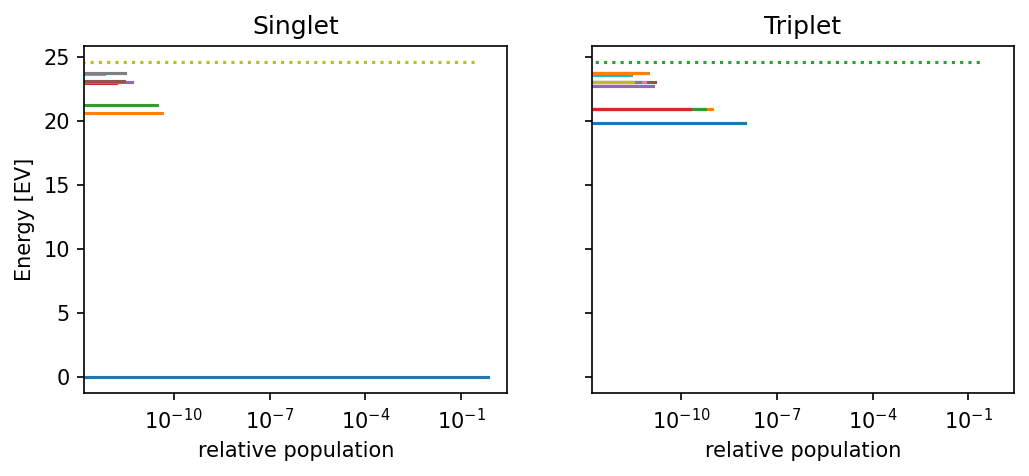

In [22]:
##  plot He level populations  ####################################################

atom = atom_He
SE = SE_He
mask = atom.Level['stage'] == 1           # select neutoral
ilevel_heii = np.where(atom.Level['stage'] == 2)[0][0]      # HeI ionization = groud state of HeII

level_erg = atom.Level['erg'][mask]
level_erg = np.append( level_erg, atom.Level['erg'][ilevel_heii] )
level_ev  = level_erg / Cst.eV2erg_
level_energy = level_ev

level_pop = SE.n_SE[mask]
level_pop = np.append( level_pop,  SE.n_SE[np.logical_not(mask)].sum())

fig, axs = plt.subplots(1,2, figsize=[8,3], dpi=150, sharey=True, sharex=True)

#axt = axs.twinx()
for i in range(level_erg.shape[0]):
    s2p1 = int(atom._ctj_table.Level[i][1][0])   #  1 - HeI singlet, 2 - HeII or 3 - HeI triplet
    if s2p1 == 1:
        axs[0].set_title('Singlet')
        axs[0].plot([0,level_pop[i]],level_energy[i]*np.ones(2))
    elif s2p1 == 3:
        axs[1].set_title('Triplet')
        axs[1].plot([0,level_pop[i]],level_energy[i]*np.ones(2))
    elif s2p1 == 2:
        axs[0].plot([0,level_pop[i]],level_energy[i]*np.ones(2),':')
        axs[1].plot([0,level_pop[i]],level_energy[i]*np.ones(2),':')        
    else:
        continue
    #print(i, level_pop[i])
    
for ax in axs:
    ax.set_xscale('log')
    ax.set_xlabel('relative population')
axs[0].set_ylabel('Energy [EV]')
#ax.plot(level_erg,level_pop,'o')
#ax.barh(level_erg,level_pop, align='center')
#level_erg
plt.show()

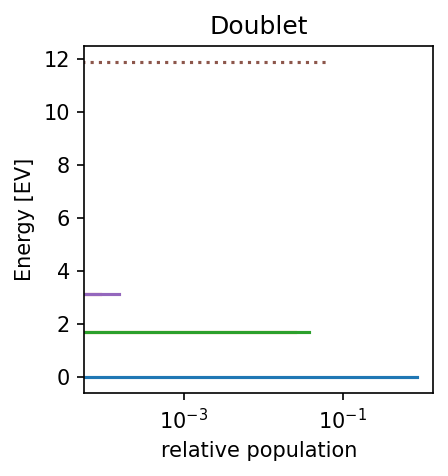

In [23]:
##  plot Ca level populations  ####################################################

atom = atom_Ca   
SE = SE_Ca
mask = atom.Level['stage'] == 2           # select neutoral
ilevel_caiii = np.where(atom.Level['stage'] == 3)[0][0]      # HeI ionization = groud state of HeII

level_erg = atom.Level['erg'][mask]
level_erg = np.append( level_erg, atom.Level['erg'][ilevel_caiii] )
level_ev  = level_erg / Cst.eV2erg_
level_energy = level_ev

level_pop = SE.n_SE[mask]
level_pop = np.append( level_pop,  SE.n_SE[np.logical_not(mask)].sum())

fig, ax = plt.subplots(1,1, figsize=[3,3], dpi=150, sharey=True, sharex=True)

#axt = axs.twinx()
for i in range(level_erg.shape[0]):
    s2p1 = int(atom._ctj_table.Level[i][1][0])   #  1 - HeI singlet, 2 - HeII or 3 - HeI triplet
    if s2p1 == 2:
        ax.set_title('Doublet')
        ax.plot([0,level_pop[i]],level_energy[i]*np.ones(2))
    elif s2p1 == 1:
        ax.plot([0,level_pop[i]],level_energy[i]*np.ones(2),':')
    else:
        continue
    #print(i, level_pop[i])
    
ax.set_xscale('log')
ax.set_xlabel('relative population')
ax.set_ylabel('Energy [EV]')
#ax.plot(level_erg,level_pop,'o')
#ax.barh(level_erg,level_pop, align='center')
#level_erg
plt.show()

In [24]:
SE.n_SE

array([8.70719277e-01, 2.50406120e-02, 3.80304618e-02, 8.98052314e-05,
       1.53356989e-04, 6.59664868e-02])

In [25]:
#------------------------------------------------------------
def transition_heatmap(atom, SE_con, Rate_con, vmin=None, vmax=None, klevel_max=None,cmap='cool',title_prefix='',figsize=(10,6),level_order='energy'):

    #SE_con = SE_He
    #Rate_con = Rate_He
    numeric_error=1E-17
    if klevel_max is None: klevel_max = atom.nLevel
    #klevel_max = 21
    
    if level_order == 'multiplet':    # -- consider only HeI
        ctj_level = atom._ctj_table.Level
        idx_singlet = []
        idx_triplet = []
        idx_doublet = []    #  He ion 
        s2p1_list = []
        for i in range(klevel_max):
            #print(atom.Level['stage'][i])
            ctj = ctj_level[i]
            s2p1 = ctj[1][0]
            if s2p1 == '1':   # singlet
                idx_singlet.append(i)
            elif s2p1 == '3':
                idx_triplet.append(i)
            elif s2p1 == '2':
                idx_doublet.append(i)
            else:
                continue
        idx_sort = idx_singlet + idx_triplet + idx_doublet
        #icont = np.where( (atom.Level['stage']==2) * (atom.Level['isGround']==1) )[0][0]
        #print(f"idx of continuum is {icont}")
        #idx_sort.append(icont)
        n_SE = SE_con.n_SE[idx_sort]
        Rmat = Rate_con.Rmat[idx_sort,:][:,idx_sort]
        Cmat = Rate_con.Cmat[idx_sort,:][:,idx_sort]
        n_SE = SE_con.n_SE[idx_sort].reshape(1,-1)
        ctj_level = [ctj_level[i] for i in idx_sort]
        ctjs = [f"{ctj[1]} {ctj[2]}" for ctj in ctj_level[:klevel_max]]
    else:
        Rmat = Rate_con.Rmat[:klevel_max,:klevel_max]
        Cmat = Rate_con.Cmat[:klevel_max,:klevel_max]
        n_SE = SE_con.n_SE[:klevel_max].reshape(1,-1)
        ctjs = [f"{ctj[1]} {ctj[2]}" for ctj in atom._ctj_table.Level[:klevel_max]]

    tran_mat = {
        "Radiative" : Rmat * n_SE,
        "Collision" : Cmat * n_SE,
    }

    #if vmin is None: vmin = min( [mat.min() for mat in tran_mat.values()] )
    #if vmax is None: vmax = max( [mat.max() for mat in tran_mat.values()] )
    if vmin is None: vmin = 1e-6
    if vmax is None: vmax = 1e-2
    norm = LogNorm(vmin, vmax, clip=True)

    fig, axs = plt.subplots(1,2, figsize=figsize, dpi=100, sharey=True)
    
    for ax, name in zip( axs, ("Radiative", "Collision") ):
        im = ax.imshow( tran_mat[name] + numeric_error, origin="lower", cmap=cmap, norm=norm )
        if name == "Radiative" and title_prefix != '':
            ax.set_title(name+f" | {title_prefix}")
        else:
            ax.set_title(name)
        ax.set_xticks([i for i in range(klevel_max)])
        ax.set_xticklabels(ctjs, rotation=75, fontsize=8)
        ax.set_yticks([i for i in range(klevel_max)])
        ax.set_yticklabels(ctjs, rotation=0, fontsize=8)


    # colorbar
    cax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
    fig.colorbar( im, cax=cax, orientation='vertical')

    plt.show()
    return None



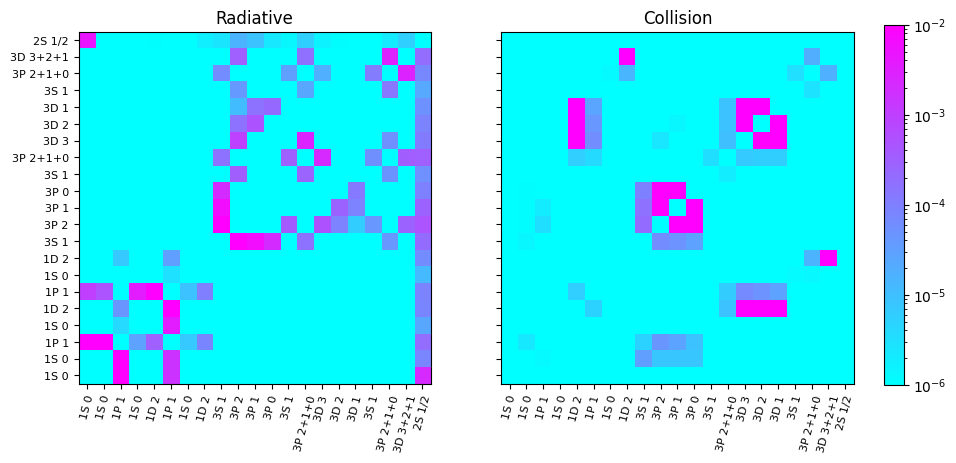

In [26]:
# Transition rale  He

transition_heatmap(atom_He, SE_He, Rate_He, vmin=1e-6, vmax=1e-2, klevel_max=21, level_order='multiplet')

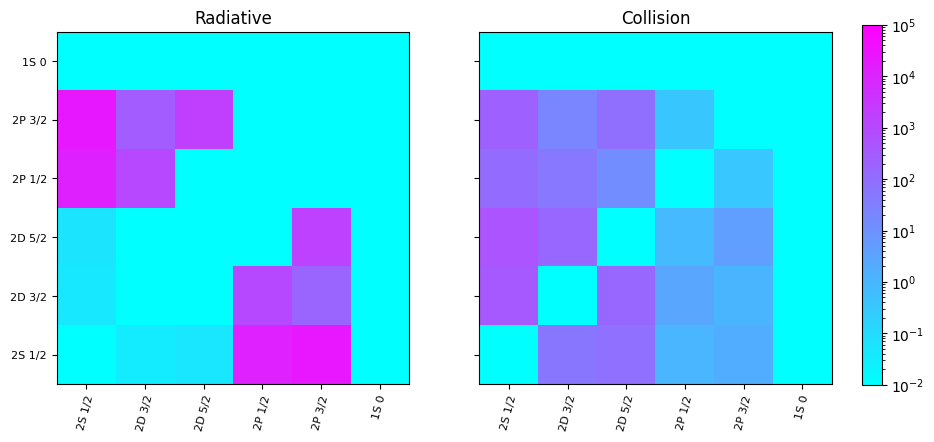

In [27]:
# Ca
transition_heatmap(atom_Ca, SE_Ca, Rate_Ca,vmin=1e-2,vmax=1e5)#, klevel_max=21, level_order='multiplet')


## level population of H and He as function of $T_e$ and $n_H$

In [28]:
### level population & intensity container
def popl_con(atom, nNh, nTe, nw):
    
    pop_arr = {
        "LTE" : np.empty((atom.nLevel, nNh, nTe), dtype="float64"),
        "SE"  : np.empty((atom.nLevel, nNh, nTe), dtype="float64"),
    }
    l_arr = {
        "intens": np.empty((nw, nNh, nTe), dtype="float64"),
        "tau": np.empty((nw, nNh, nTe), dtype="float64"),
        "src": np.empty((nNh, nTe), dtype="float64"),
    }
    return pop_arr, l_arr


In [29]:
#******  calculate populations in SE & LTS on (Te, Nh) ******
nTe = 51
Te_arr = np.linspace(2000, 40000, nTe)
nNh = nTe
Nh_arr = np.logspace(9, 14, nNh)
Vt = 5e5            #   cm/s
depth = 1.E3 * 1.E5 #   km *1e5

pop_arr_H, l_arr_H = popl_con(atom_H,nNh, nTe, w6563.size)
pop_arr_He, l_arr_He = popl_con(atom_He,nNh, nTe, w10830.size)
#pop_arr_Ca, l_arr_Ca = popl_con(atom_Ca,nNh, nTe, w8542.size)
pop_arr_Ca, l_arr_Ca = popl_con(atom_Ca,nNh, nTe, w3934.size)
Ne_arr = np.empty((nNh, nTe), dtype="float64")
ampl = 1
solar_spec_He = enhance_EUV(solar_spec_He0,wMesh_He,ampl)


for j in range(nNh):  
    Nh = Nh_arr[j]
    for k in range(nTe):
        print(f'\r {j}/{nNh}, {k}/{nTe}', end='\r')
        Te = Te_arr[k]
        slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vt=Vt)     # slab 
        SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
        lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
        l6563 = extract_line(lH,w6563,Ic=Ic6563)
        l_arr_H["intens"][:,j,k] = l6563["intens"]
        l_arr_H["tau"][:,j,k] = l6563["tau"]
        l_arr_H["src"][j,k] = l6563["src"]

        SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
        lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # hydrogen lines intensity
        #l8542 = extract_line(lCa,w8542,Ic=Ic8542)
        #l_arr_Ca["intens"][:,j,k] = l8542["intens"]
        #l_arr_Ca["tau"][:,j,k] = l8542["tau"]
        #l_arr_Ca["src"][j,k] = l8542["src"]
        l3934 = extract_line(lCa,w3934,Ic=Ic3934)
        l_arr_Ca["intens"][:,j,k] = l3934["intens"]
        l_arr_Ca["tau"][:,j,k] = l3934["tau"]
        l_arr_Ca["src"][j,k] = l3934["src"]

        SE_He, Rate_He = SELib.cal_SE_with_Nh_Te_(atom_He, slab, wMesh_He, solar_spec_He, SE_H.n_SE)  #  level populations etc.
        lHe = CloudModel.SE_to_slab_0D_(atom_He, slab, SE_He, depth=depth)      # hydrogen lines intensity
        l10830 = extract_line(lHe,w10830,Ic=Ic10830)
        l_arr_He["intens"][:,j,k] = l10830["intens"]
        l_arr_He["tau"][:,j,k] = l10830["tau"]
        l_arr_He["src"][j,k] = l10830["src"]

        Ne_arr[j,k] = atmos.Ne
        pop_arr_H["LTE"][:,j,k] = SE_H.n_LTE[:]
        pop_arr_H["SE"][:,j,k] = SE_H.n_SE[:]
        pop_arr_He["LTE"][:,j,k] = SE_He.n_LTE[:]
        pop_arr_He["SE"][:,j,k] = SE_He.n_SE[:]
        pop_arr_Ca["LTE"][:,j,k] = SE_Ca.n_LTE[:]
        pop_arr_Ca["SE"][:,j,k] = SE_Ca.n_SE[:]


wleuv= 5.04e-06


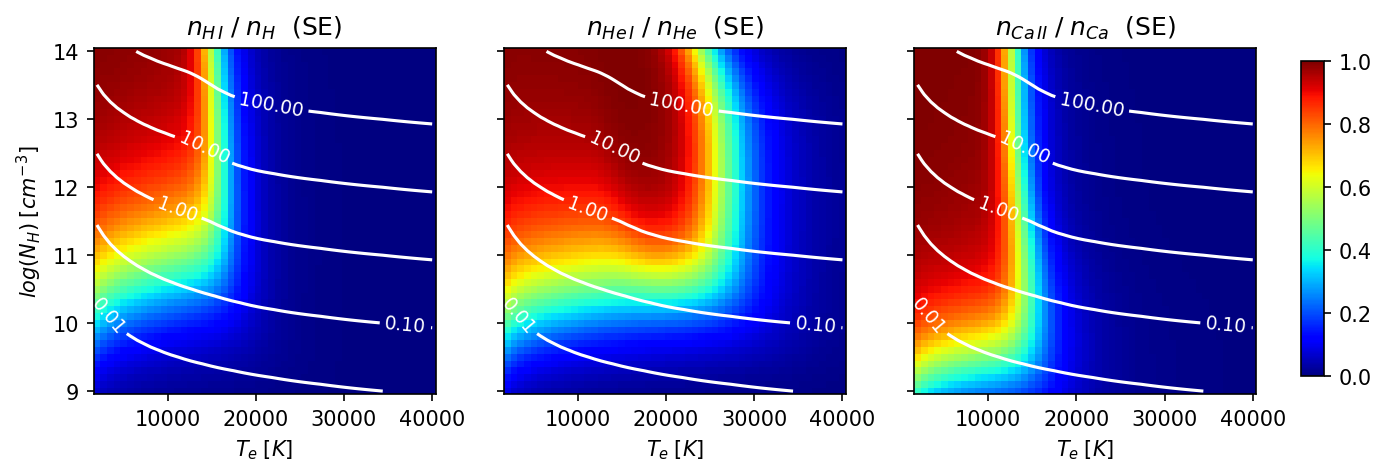

In [30]:
#  display neutral fraction of H and He on (Te, nH) plane

#--- sum up neutral populations ---
EQ = "SE"
mask_HI = (atom_H.Level['stage'] == 1)
mask_HeI = (atom_He.Level['stage'] == 1)
mask_CaII = (atom_Ca.Level['stage'] == 2)
nHI = np.sum(pop_arr_H[EQ][mask_HI,:,:], axis=0)
nHeI = np.sum(pop_arr_He[EQ][mask_HeI,:,:], axis=0)
nCaII = np.sum(pop_arr_Ca[EQ][mask_CaII,:,:], axis=0)


Te,Nh = np.meshgrid(Te_arr,np.log10(Nh_arr))

Ne0      = 1.E-4 * Nh                # [/cm^{3}]
Ne = Ne0 + 10**Nh * pop_arr_H[EQ][-1,:,:]   # [/cm^{3}]
Pg = (10**Nh *1.107 + Ne)*Cst.k_*Te

fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"
plevels = [0.01,0.1,1,10,100]

ax=axs[0]
mapH = ax.pcolormesh(Te,Nh,nHI,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{H\, I} \; / \; n_{H} $  ("+EQ+")")
ax.set_ylabel("$log(N_{H}) \; [cm^{-3}]$")
ax.set_xlabel("$T_{e} \; [K]$")
ax.set_yticks([9,10,11,12,13,14])
CS = ax.contour(Te,Nh,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

ax=axs[1]
mapHe = ax.pcolormesh(Te,Nh,nHeI,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{He\, I} \; / \; n_{He} $  ("+EQ+")")
ax.set_xlabel("$T_{e} \; [K]$")
CS = ax.contour(Te,Nh,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

ax=axs[2]
mapCa = ax.pcolormesh(Te,Nh,nCaII,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{Ca\, II} \; / \; n_{Ca} $  ("+EQ+")")
ax.set_xlabel("$T_{e} \; [K]$")
CS = ax.contour(Te,Nh,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

cax = fig.add_axes([0.93,0.15,0.015,0.7])
fig.colorbar(mapH, cax=cax, orientation="vertical")


plt.show()

In [31]:
np.array(src6563).shape
a=np.max(l_arr_H["tau"],axis=0)
a.shape

NameError: name 'src6563' is not defined

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"
vmx = 0.5

ax=axs[0]
s6563 = (l_arr_H["src"]-Ic6563)/Ic6563 *np.max(l_arr_H["tau"],axis=0)
sH = ax.pcolormesh(Te,Nh,s6563,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"H$_\alpha$: $(S-I_c)/I_c * \tau_0$")
ax.set_ylabel("$log(N_{H}) \; [cm^{-3}]$")
ax.set_xlabel("$T_{e} \; [K]$")
ax.set_yticks([9,10,11,12,13,14])
c1 = ax.contour(Te,Nh,s6563,levels=[0],colors='black')
CS = ax.contour(Te,Nh,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

ax=axs[1]
s10830 = (l_arr_He["src"]-Ic10830)/Ic10830 *np.max(l_arr_He["tau"],axis=0)
sHe = ax.pcolormesh(Te,Nh,s10830,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"He10830: $(S-I_c)/I_c * \tau_0$")
ax.set_xlabel("$T_{e} \; [K]$")
c1 = ax.contour(Te,Nh,s10830,levels=[0],colors='black')
CS = ax.contour(Te,Nh,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

ax=axs[2]
#s8542 = (l_arr_Ca["src"]-Ic8542)/Ic8542 *np.max(l_arr_Ca["tau"],axis=0)
#sCa = ax.pcolormesh(Te,Nh,s8542,cmap=cmap,vmin=-vmx,vmax=vmx)
#ax.set_title(r"Ca8542: $(S-I_c)/I_c * \tau_0$")
#ax.set_xlabel("$T_{e} \; [K]$")
#c1 = ax.contour(Te,Nh,s8542,levels=[0],colors='black')
s3934 = (l_arr_Ca["src"]-Ic3934)/Ic3934 *np.max(l_arr_Ca["tau"],axis=0)
sCa = ax.pcolormesh(Te,Nh,s3934,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"Ca3934: $(S-I_c)/I_c * \tau_0$")
ax.set_xlabel("$T_{e} \; [K]$")
c1 = ax.contour(Te,Nh,s3934,levels=[0],colors='black')
CS = ax.contour(Te,Nh,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

cax = fig.add_axes([0.93,0.15,0.015,0.6])
fig.colorbar(sH, cax=cax, orientation="vertical")

In [ ]:
l = line_list(atom_Ca)

In [ ]:
#********************************************************
#  lower level populations,  Ha and 10830,  

lidx_H,lower_H,uidx_H,upper_H = level_info(atom_H, 6563.)
lidx_He,lower_He,uidx_He,upper_He = level_info(atom_He,10830.3)
lidx_Ca,lower_Ca,uidx_Ca,upper_Ca = level_info(atom_Ca,3934.7)

EQ ="SE"
nH_l = pop_arr_H[EQ][lidx_H,:,:]
nHe_l = pop_arr_He[EQ][lidx_He,:,:]
nCa_l = pop_arr_Ca[EQ][lidx_Ca,:,:]


#fig, axs = plt.subplots(1,2, figsize=(8,4), dpi=150, sharex=True, sharey=True)
fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)

plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"
ax=axs[0]
#mapH = ax.pcolormesh(Te_arr,Nh_arr,nHI,cmap=cmap,vmin=0,vmax=1.)
im_H = ax.imshow(nH_l, cmap=cmap, origin="lower")#, vmin=0, vmax=1.)
Plotting.set_imshow_ticks_(ax, Te_arr, axis='x',points=5, fmt='%1.0f',rot=0)
Plotting.set_imshow_ticks_(ax, np.log10(Nh_arr), axis='y', points=5, fmt='%1.0f',rot=0)

ax.set_title("$ n_{H\, (n=2)} \; / \; n_{H} $  ("+EQ+")")
ax.set_ylabel("$log(N_{H}) \; [cm^{-3}]$")
ax.set_xlabel("$T_{e} \; [K]$")

ax = axs[1]
im_He = ax.imshow(nHe_l, cmap=cmap, origin="lower")#, vmin=0, vmax=1.)
ax.set_title("$ n_{He\, 3S1} \; / \; n_{He} $  ("+EQ+")")
ax.set_xlabel("$T_{e} \; [K]$")

ax = axs[2]
im_He = ax.imshow(nCa_l, cmap=cmap, origin="lower")#, vmin=0, vmax=1.)
ax.set_title("$ n_{CaII\, 2S0.5} \; / \; n_{Ca} $  ("+EQ+")")
ax.set_xlabel("$T_{e} \; [K]$")

cax = fig.add_axes([0.95,0.2,0.02,0.5])
fig.colorbar(im_H, cax=cax, orientation="vertical")

plt.show()

In [ ]:
#******************************************************
#  plot population;  neutoral, lower level of Ha & 10830  

j = 10  #  Nh[j]

fig, ax = plt.subplots(1,1, figsize=[5,3], dpi=150)
ax.plot(Te_arr,nHI[j,:],label='HI')
ax.plot(Te_arr,nHeI[j,:],label='HeI')
ax.plot(Te_arr,nH_l[j,:],label='H (n=2)')
ax.plot(Te_arr,nHe_l[j,:],label='He ('+lower_He+')')

ax.set_yscale("log")
ax.set_xlabel("Te [K]", fontsize=12)
plt.title(f"$n_H=${Nh_arr[j]:5.1E} [cm-3]")
#plt.legend()

# SE with (Pg, Te)

In [ ]:
#******  calculate populations in SE & LTE on (Te, Pg) ******
nTe = 51
Te_arr = np.linspace(2000, 50000, nTe)
nPg = nTe
Pg_arr = np.logspace(-2, 3, nPg)   # dyn/cm^2
Vt = 5e5            #   cm/s
depth = 1.E3 * 1.E5 #   km *1e5

pop_arr_H, l_arr_H = popl_con(atom_H,nPg, nTe,w6563.size)
pop_arr_He, l_arr_He = popl_con(atom_He,nPg, nTe,w10830.size)
pop_arr_Ca, l_arr_Ca = popl_con(atom_Ca,nPg, nTe,w8542.size)
Ne_arr = np.empty((nPg, nTe), dtype="float64")

ampl = 1
solar_spec_H = enhance_EUV(solar_spec_H0,wMesh_H,ampl)
solar_spec_He = enhance_EUV(solar_spec_He0,wMesh_He,ampl)
solar_spec_Ca = enhance_EUV(solar_spec_Ca0,wMesh_Ca,ampl)

for j in range(nPg):  
#for j in (17,): #range(nPg):  
    Pg = Pg_arr[j]
    for k in range(nTe):
        print(f'\r {j}/{nPg}, {k}/{nTe}', end='\r')
        Te = Te_arr[k]
        slab = Atmosphere.Atmosphere0D(Pg=Pg, Nh=1e11, Ne=1e10, Te=Te, Vt=Vt)     # slab 
        # slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vt=Vt)     # slab 
        
        SE_H, Rate_H = SELib.cal_SE_with_Pg_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
        lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
        l6563 = extract_line(lH,w6563,Ic=Ic6563)
        l_arr_H["intens"][:,j,k] = l6563["intens"]
        l_arr_H["tau"][:,j,k] = l6563["tau"]
        l_arr_H["src"][j,k] = l6563["src"]
        #print('H')

        SE_Ca, Rate_Ca = SELib.cal_SE_with_Pg_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
        lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # hydrogen lines intensity
        l8542 = extract_line(lCa,w8542,Ic=Ic8542)
        l_arr_Ca["intens"][:,j,k] = l8542["intens"]
        l_arr_Ca["tau"][:,j,k] = l8542["tau"]
        l_arr_Ca["src"][j,k] = l8542["src"]

        SE_He, Rate_He = SELib.cal_SE_with_Pg_Te_(atom_He, slab, wMesh_He, solar_spec_He, SE_H.n_SE)  #  level populations etc.
        lHe = CloudModel.SE_to_slab_0D_(atom_He, slab, SE_He, depth=depth)      # hydrogen lines intensity
        l10830 = extract_line(lHe,w10830,Ic=Ic10830)
        l_arr_He["intens"][:,j,k] = l10830["intens"]
        l_arr_He["tau"][:,j,k] = l10830["tau"]
        l_arr_He["src"][j,k] = l10830["src"]

        Ne_arr[j,k] = atmos.Ne
        pop_arr_H["LTE"][:,j,k] = SE_H.n_LTE[:]
        pop_arr_H["SE"][:,j,k] = SE_H.n_SE[:]
        pop_arr_He["LTE"][:,j,k] = SE_He.n_LTE[:]
        pop_arr_He["SE"][:,j,k] = SE_He.n_SE[:]
        pop_arr_Ca["LTE"][:,j,k] = SE_Ca.n_LTE[:]
        pop_arr_Ca["SE"][:,j,k] = SE_Ca.n_SE[:]


In [ ]:
#  display neutral fraction of H and He on (Te, nH) plane

#--- sum up neutral populations ---
EQ = "SE"
mask_HI = (atom_H.Level['stage'] == 1)
mask_HeI = (atom_He.Level['stage'] == 1)
mask_CaII = (atom_Ca.Level['stage'] == 2)
nHI = np.sum(pop_arr_H[EQ][mask_HI,:,:], axis=0)
nHeI = np.sum(pop_arr_He[EQ][mask_HeI,:,:], axis=0)
nCaII = np.sum(pop_arr_Ca[EQ][mask_CaII,:,:], axis=0)
nH_l = pop_arr_H[EQ][lidx_H,:,:]
nHe_l = pop_arr_He[EQ][lidx_He,:,:]
nCa_l = pop_arr_Ca[EQ][lidx_Ca,:,:]



Te,Pg = np.meshgrid(Te_arr,np.log10(Pg_arr))

#Ne0      = 1.E-4 * Nh                # [/cm^{3}]
#Ne = Ne0 + 10**Nh * pop_arr_H[EQ][-1,:,:]   # [/cm^{3}]

fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"

ax=axs[0]
mapH = ax.pcolormesh(Te,Pg,nHI,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{H\, I} \; / \; n_{H} $  ("+EQ+")")
ax.set_ylabel("$log(P_{g}) \; [dyn / cm^{2}]$")
ax.set_xlabel("$T_{e} \; [K]$")
ax.set_yticks([-2,-1,0,1,2,3,4])

ax=axs[1]
mapHe = ax.pcolormesh(Te,Pg,nHeI,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{He\, I} \; / \; n_{He} $  ("+EQ+")")
ax.set_xlabel("$T_{e} \; [K]$")

ax=axs[2]
mapCa = ax.pcolormesh(Te,Pg,nCaII,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{Ca\, II} \; / \; n_{Ca} $  ("+EQ+")")
ax.set_xlabel("$T_{e} \; [K]$")

cax = fig.add_axes([0.93,0.15,0.015,0.7])
fig.colorbar(mapH, cax=cax, orientation="vertical")


plt.show()

In [ ]:
#******************************************************
#  plot neutoral fraction, lower level of Ha & 10830  

j = 15  #  Pg[j]

fig, ax = plt.subplots(1,1, figsize=[5,3], dpi=150)
ax.plot(Te_arr,nHI[j,:],label='HI',color='red')
#ax.plot(Te_arr,nCaII[j,:],label='CaII')
ax.plot(Te_arr,nHeI[j,:],label='HeI',color='blue')

ax.plot(Te_arr,nH_l[j,:],'--',label='H (n=2)',color='red')
#ax.plot(Te_arr,nCa_l[j,:],label='CaII (ground)')
ax.plot(Te_arr,nHe_l[j,:],'--',label='He ('+lower_He+')',color='blue')

ax.set_yscale("log")
#ax.set_ylim([0,1])
ax.set_xlabel("Te [K]", fontsize=12)
ax.set_ylabel("fraction", fontsize=12)
plt.title(f"Neutral & lower level fraction  $P_g=${Pg_arr[j]:5.1E} [dyn / cm-2]")
#plt.legend()

In [ ]:
##  display (S-I_c)/I_c * tau 

fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"
vmx = 0.5

ax=axs[0]
s6563 = (l_arr_H["src"]-Ic6563)/Ic6563 *np.max(l_arr_H["tau"],axis=0)
sH = ax.pcolormesh(Te,Pg,s6563,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"H$_\alpha$: $(S-I_c)/I_c * \tau_0$")
ax.set_ylabel("$log(P_{g}) \; [dyn/cm^{2}]$")
ax.set_xlabel("$T_{e} \; [K]$")
ax.set_yticks([-2,-1,0,1,2,3,4])
c1 = ax.contour(Te,Pg,s6563,levels=[0],colors='black')

ax=axs[1]
s10830 = (l_arr_He["src"]-Ic10830)/Ic10830 *np.max(l_arr_He["tau"],axis=0)
sHe = ax.pcolormesh(Te,Pg,s10830,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"He10830: $(S-I_c)/I_c * \tau_0$")
ax.set_xlabel("$T_{e} \; [K]$")
c1 = ax.contour(Te,Pg,s10830,levels=[0],colors='black')

ax=axs[2]
s8542 = (l_arr_Ca["src"]-Ic8542)/Ic8542 *np.max(l_arr_Ca["tau"],axis=0)
sCa = ax.pcolormesh(Te,Pg,s8542,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"Ca8542: $(S-I_c)/I_c * \tau_0$")
ax.set_xlabel("$T_{e} \; [K]$")
c1 = ax.contour(Te,Pg,s8542,levels=[0],colors='black')

cax = fig.add_axes([0.93,0.15,0.015,0.6])
fig.colorbar(sH, cax=cax, orientation="vertical")

In [ ]:
#******************************************************
#  plot population;  neutoral, lower level of Ha & 10830  

j = 10  #  Pg[j]

fig, ax = plt.subplots(1,1, figsize=[5,3], dpi=150)
ax.plot(Te_arr/1000,s6563[j,:],label='HI 6563')
ax.plot(Te_arr/1000,s8542[j,:],label='CaII 8542')
ax.plot(Te_arr/1000,s10830[j,:],label='HeI 10830')
#ax.plot(Te_arr,nH_l[j,:],label='H (n=2)')
#ax.plot(Te_arr,nHe_l[j,:],label='He ('+lower_He+')')

#ax.set_yscale("log")
ax.set_xlabel("$T_e$ [MK]", fontsize=12)
ax.set_ylabel(r"$(S-I_c) \tau$", fontsize=12)
plt.title(f"$P_g=${Pg_arr[j]:5.2F} [$dyn/cm^2$]")
plt.legend()

In [ ]:
EW_6563.shape

In [ ]:
Iprof6563 = np.interp(w6563,wl0,Isolar)

fig,ax = plt.subplots(1,1, figsize=(5,3), dpi=150)

ax.plot(w6563,Iprof6563)
ax.plot(w6563,l_arr_H["intens"][:,30,10])

In [ ]:
##  display EW


ddv = dv*1e5/Cst.c_


EW_6563 = np.sum(l_arr_H["intens"][:,:,:]-Ic6563, axis=0)/Ic6563 *ddv*6563.
EW_10830 = np.sum(l_arr_He["intens"][:,:,:]-Ic10830, axis=0)/Ic10830 *ddv*10830.
EW_8542 = np.sum(l_arr_Ca["intens"][:,:,:]-Ic8542, axis=0)/Ic8542 *ddv*8542.

fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"
vmx = 1

ax=axs[0]
sH = ax.pcolormesh(Te,Pg,EW_6563,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"H$_\alpha$: EW")
ax.set_ylabel("$log(P_{g}) \; [dyn/cm^{2}]$")
ax.set_xlabel("$T_{e} \; [K]$")
ax.set_yticks([-2,-1,0,1,2,3,4])
c1 = ax.contour(Te,Pg,EW_6563,levels=[0],colors='black')

ax=axs[1]
sHe = ax.pcolormesh(Te,Pg,EW_10830,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"He10830: EW")
ax.set_xlabel("$T_{e} \; [K]$")
c1 = ax.contour(Te,Pg,EW_10830,levels=[0],colors='black')

ax=axs[2]
sCa = ax.pcolormesh(Te,Pg,EW_8542,cmap=cmap,vmin=-vmx,vmax=vmx)
ax.set_title(r"Ca8542: EW")
ax.set_xlabel("$T_{e} \; [K]$")
c1 = ax.contour(Te,Pg,EW_8542,levels=[0],colors='black')

cax = fig.add_axes([0.93,0.15,0.015,0.6])
fig.colorbar(sH, cax=cax, orientation="vertical")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=[5,3], dpi=150)

j = 10  # Pg

ax.plot(Te_arr/1000,EW_6563[j,:], label='HI 6563A')
ax.plot(Te_arr/1000,EW_8542[j,:], label='CaII 8542A')
ax.plot(Te_arr/1000,EW_10830[j,:], label='HeI 10830A')

ax.set_xlabel("$T_e$ [MK]", fontsize=12)
ax.set_ylabel("EW [A]", fontsize=12)
plt.title(f"$P_g=${Pg_arr[j]:5.2F} [$dyn/cm^2$]")
plt.legend()


In [ ]:
pop_arr_H['SE'].shape

In [ ]:
from spectra.Visual import Grotrian
gro = Grotrian.Grotrian(atom, path_dict_He["Grotrian"], )
gro.make_fig(_figsize=(10,6),_dpi=150, _f=50)


In [ ]:
1./1.602176634e-19